In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [43]:
outliermeth = 'mod_zscore_outlier'
normtype = 'zscore'

base_dir = Path().resolve()
folderpath = os.path.join(base_dir, "..","Biometrics", "Outputs", outliermeth)
folderpath = os.path.abspath(folderpath)
folderpath


'C:\\Users\\josee\\OneDrive\\Documentos\\GitHub\\neurohumanities-lab\\OfflineProcessing\\Biometrics\\Outputs\\mod_zscore_outlier'

In [44]:
scenedata = {}
for scene in range(1,5):
    scenedata.update({scene:pd.read_csv(os.path.join(folderpath,f"biometric_feat_mat_scene_{scene}_{normtype}.csv"))})

In [45]:
scenedata[1]

,Subject,bpm,sdnn,rmssd,pnn50,hr_mad,lf,hf,lf/hf,p_total,lf_nu,hf_nu,mean_eda,mean_tonic,scr_peak_count,scr_sum_amp,scr_mean_amp,scr_mean_risetime,scr_mean_recoverytime
0,1,-0.168384,-0.296877,-0.305280,-0.446817,-0.346891,0.446173,1.334061,-0.446288,2.227442,-0.385937,-0.325042,-0.447162,-0.447162,-0.432533,-0.446889,-0.447168,-0.445374,-0.444548
1,1,-0.151361,-0.293845,-0.317722,-0.446744,-0.332560,3.498210,3.758261,-0.445487,7.703679,-0.358416,-0.352563,-0.447171,-0.447173,-0.416024,-0.446280,-0.447150,-0.446205,-0.444915
2,1,-0.143036,-0.301872,-0.305822,-0.446768,-0.332560,0.912463,0.987874,-0.445470,2.347545,-0.357964,-0.353015,-0.447133,-0.447133,-0.432533,-0.446052,-0.447064,-0.445947,-0.446291


In [46]:
def remove_outliers_iqr(col):
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return col[(col >= lower) & (col <= upper)]

# scenedataclean = {}
# for scene in range(1,5):
#     data = scenedata[scene].drop(columns=['Subject']).dropna()
#     cleandata = cleandata.apply(remove_outliers_iqr).dropna()
#     scenedataclean.update({scene : cleandata})


In [47]:
# scenedataclean[1]

In [48]:
scenedata[1]

,Subject,bpm,sdnn,rmssd,pnn50,hr_mad,lf,hf,lf/hf,p_total,lf_nu,hf_nu,mean_eda,mean_tonic,scr_peak_count,scr_sum_amp,scr_mean_amp,scr_mean_risetime,scr_mean_recoverytime
0,1,-0.168384,-0.296877,-0.305280,-0.446817,-0.346891,0.446173,1.334061,-0.446288,2.227442,-0.385937,-0.325042,-0.447162,-0.447162,-0.432533,-0.446889,-0.447168,-0.445374,-0.444548
1,1,-0.151361,-0.293845,-0.317722,-0.446744,-0.332560,3.498210,3.758261,-0.445487,7.703679,-0.358416,-0.352563,-0.447171,-0.447173,-0.416024,-0.446280,-0.447150,-0.446205,-0.444915
2,1,-0.143036,-0.301872,-0.305822,-0.446768,-0.332560,0.912463,0.987874,-0.445470,2.347545,-0.357964,-0.353015,-0.447133,-0.447133,-0.432533,-0.446052,-0.447064,-0.445947,-0.446291


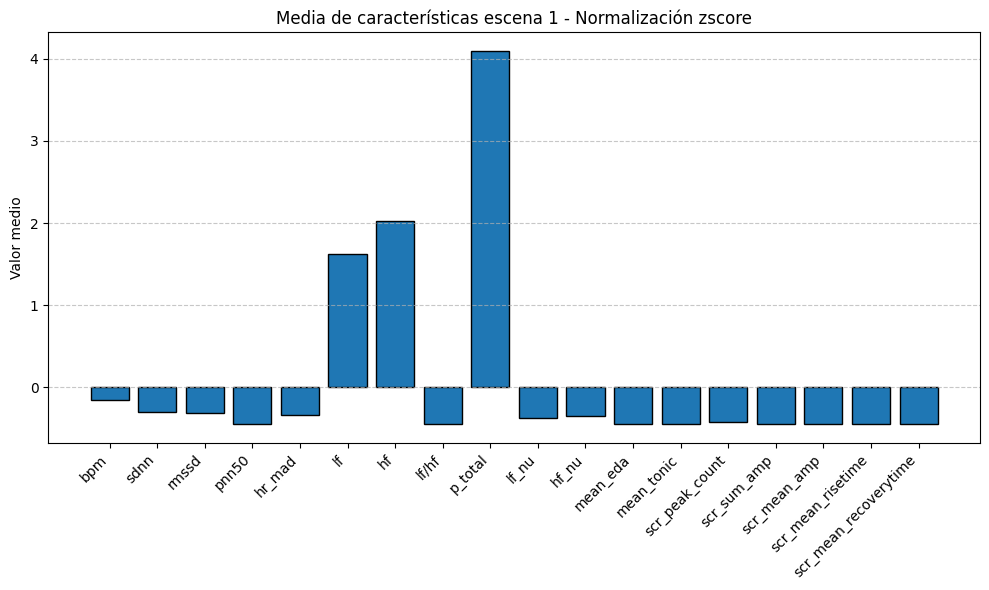

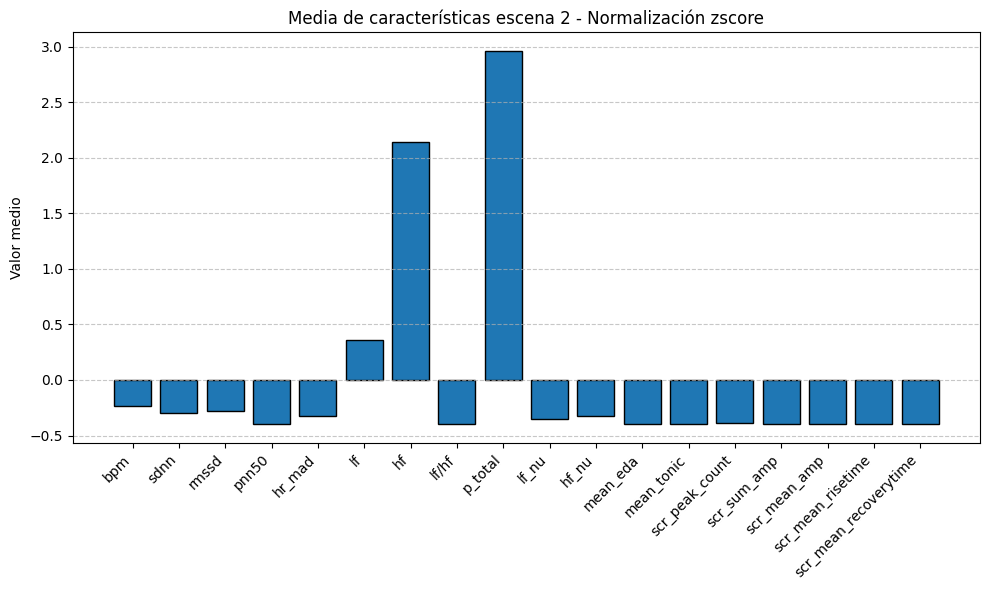

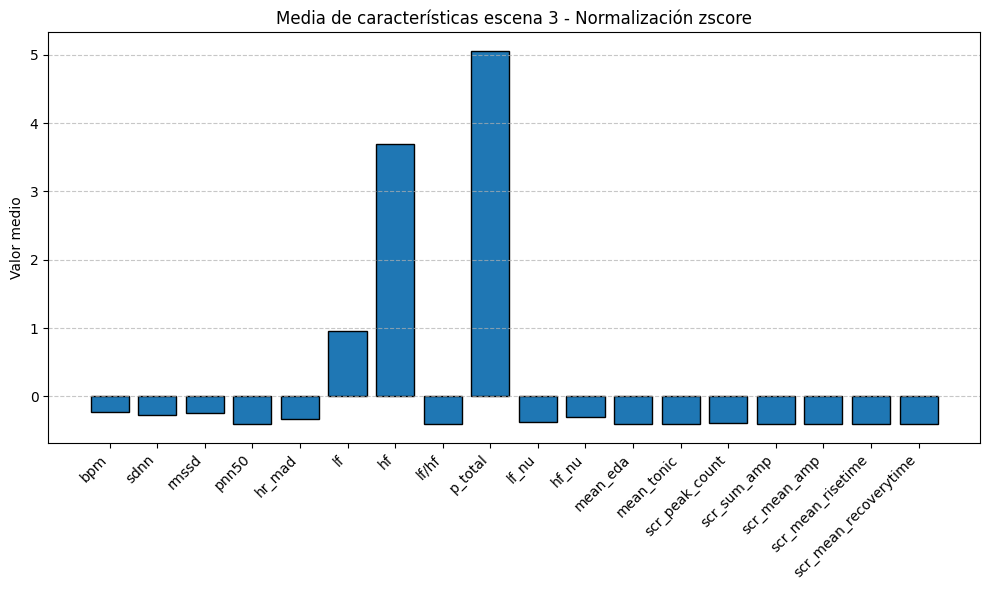

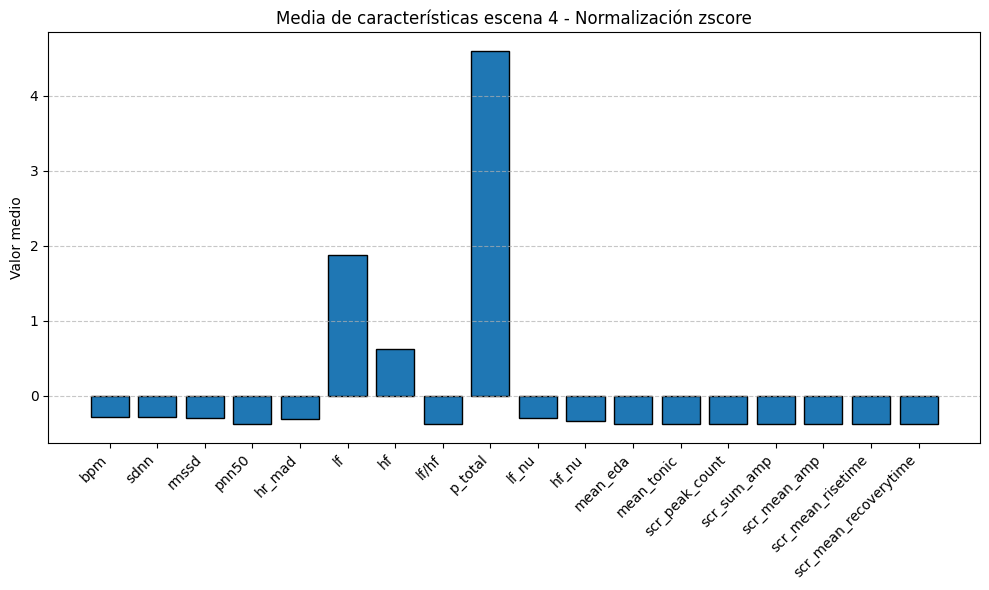

In [49]:
outpath = os.path.join(base_dir, "..","Biometrics", "Outputs", "Figures", outliermeth, normtype)
outpath = os.path.abspath(outpath)

def plot_bars(data, scene=int, normtype=str, savecond=True, savepath=str):
    means = data.mean()
    plt.figure(figsize=(10, 6))
    plt.bar(means.index, means.values, color='#1f77b4', edgecolor='black')
    plt.title(f'Media de características escena {scene} - Normalización {normtype}')
    plt.ylabel('Valor medio')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    if savecond:
        plt.savefig(os.path.join(savepath, f'bar_scene{scene}_{normtype}.png'), dpi=300, bbox_inches='tight')
    # plt.show()

for probe in range(1,5):
    plot_bars(scenedata[probe].drop('Subject',axis=1), probe, normtype, savecond=True, savepath=outpath)
    
    

In [50]:
list(scenedata)

[1, 2, 3, 4]

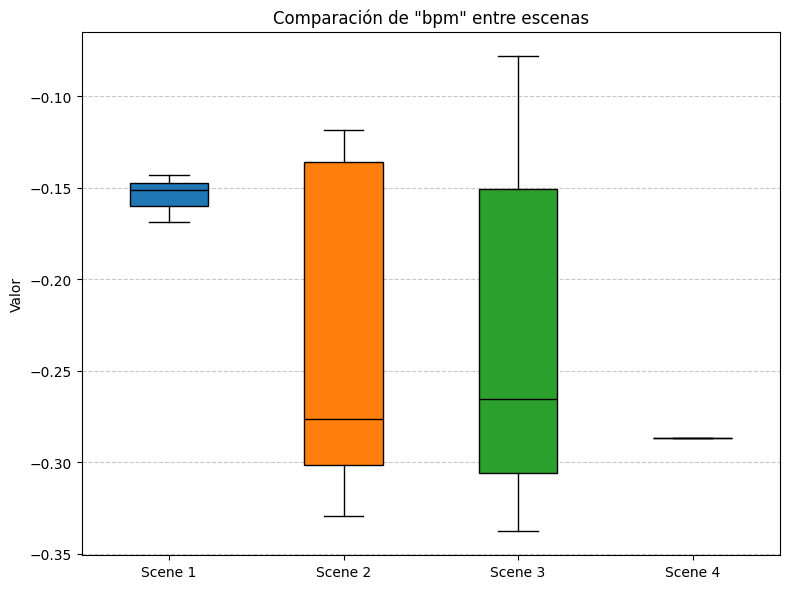

In [51]:
def boxplot_feature_by_context(dfs, labels, feature, title=None, colors=None):
    dfs_list = [dfs[i] for i in sorted(dfs.keys())]

    # Extrae los valores de la característica en cada contexto
    data = [df[feature] for df in dfs_list]

    # Colores por defecto si no se especifican
    if colors is None:
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(dfs)]

    # Gráfico
    plt.figure(figsize=(8, 6))
    box = plt.boxplot(data, patch_artist=True, tick_labels=labels)

    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')

    for component in ['whiskers', 'caps', 'medians']:
        for element in box[component]:
            element.set_color('black')

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylabel('Valor')
    plt.title(title if title else f'Comparación de "{feature}" entre escenas')
    plt.tight_layout()
    plt.show()

labels = ['Scene 1', 'Scene 2', 'Scene 3', 'Scene 4']
feats = list(scenedata[1].columns)
boxplot_feature_by_context(scenedata, labels, feats[1])

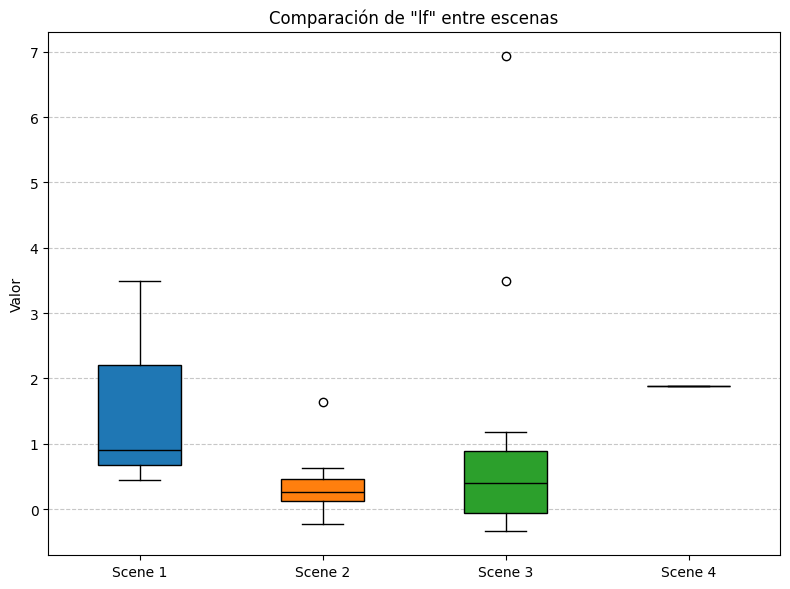

In [52]:
boxplot_feature_by_context(scenedata, labels, feats[6])

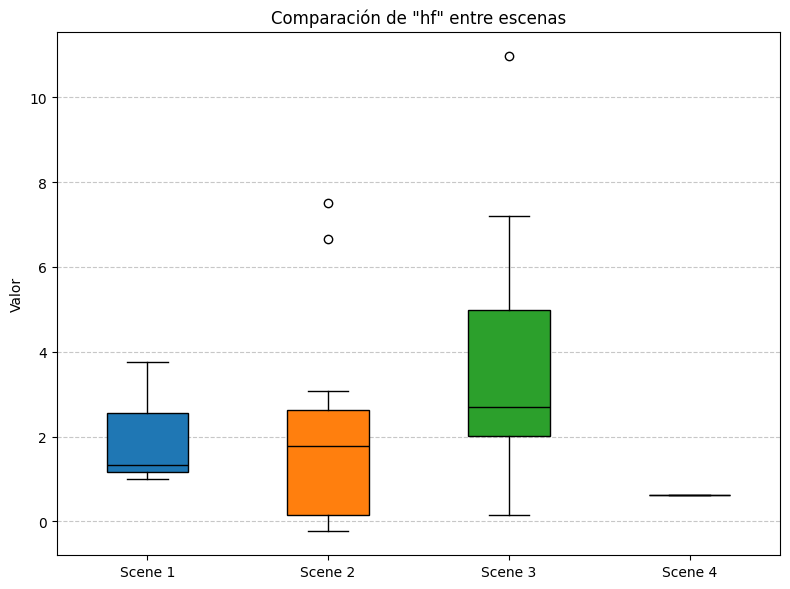

In [53]:
boxplot_feature_by_context(scenedata, labels, feats[7])

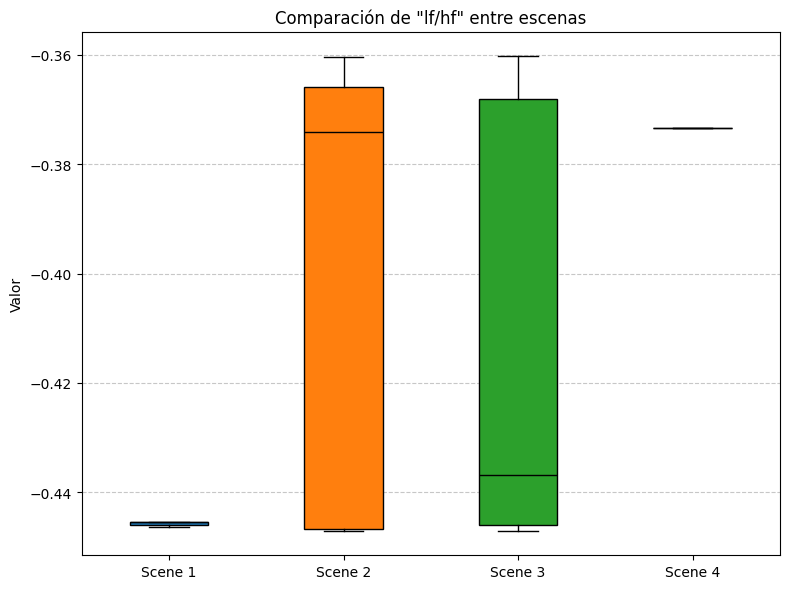

In [54]:
boxplot_feature_by_context(scenedata, labels, feats[8])

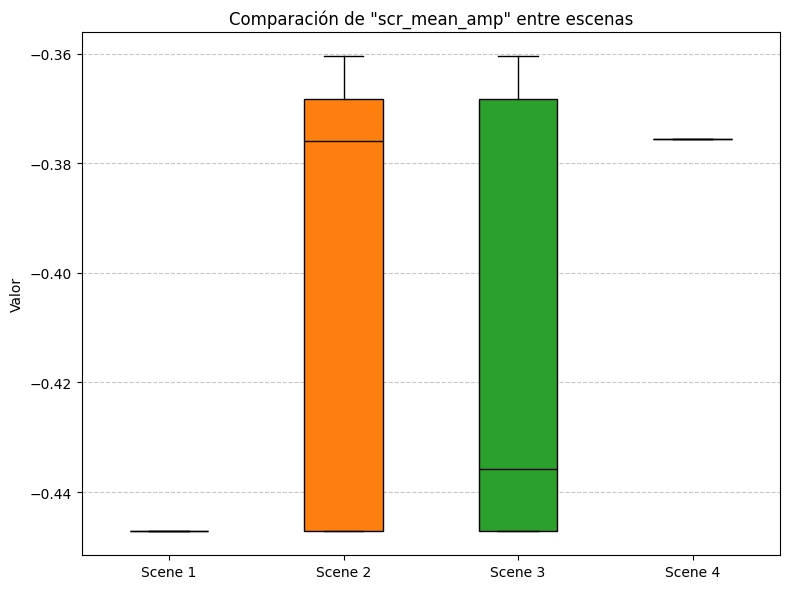

In [55]:
boxplot_feature_by_context(scenedata, labels, feats[16])